# Building a Music Genre Classifier Based on Audio Features

---

                                                 By: Komal Shahid
                                                 DSC 550 (Spring'24)


                                                    Narrative:

---

## Introduction:

The idea originated from brainstorming on how to create a model for music streaming platforms.
In this project, the aim is to create a classification model that predicts the genre of a track based on its audio features. The objective is to build a reliable and accurate machine learning model that can automatically classify music into different genres. The analysis will leverage a dataset containing audio features of various tracks in Spotify sourced from Hugging Face. I aim to understand how to use classification methods and build more sophisticated model for any streaming platforms.

## Problem Statement:

The problem to be addressed is the need for an automated system that can accurately classify music tracks into specific genres. It could be beneficial for music streaming platforms, music recommendation systems, and music enthusiasts to have an efficient and accurate genre classification model.

## Data Description:

The dataset for this analysis is sourced from Hugging Face, a popular platform for sharing and exploring NLP and machine learning models. It includes audio features extracted from a diverse collection of tracks, encompassing various music genres. The features could include tempo, duration, key, time signature, spectral features, and more. Each track is labeled with its corresponding genre, allowing for supervised learning.

## Model Building Approach:

To build the music genre classification model, we will adopt a supervised learning approach. The labeled dataset will serve as the training data for the model. We will explore different machine learning algorithms we learn throughout the course such as decision trees, random forest, or even more advanced techniques like deep learning using neural networks. The dataset will be divided into training and testing sets to evaluate the performance of the models.

## Evaluation and Target:

The target for the classification model is to accurately predict the genre of a music track based on its audio features. The model's performance will be evaluated using various metrics such as accuracy, precision, recall, and F1 score. The goal is to achieve a high accuracy rate, minimizing the misclassification of genres.

## Conclusion:

By developing a classification model that can accurately predict the genre of a track based on its audio features, this project aims to provide a valuable tool for music platforms, recommendation systems, and music enthusiasts. The model can assist in streamlining manual genre classification processes, enhancing music organization, and improving personalized music recommendations. Additionally, the analysis can contribute to a deeper understanding of the relationships between audio features and musical genres. By leveraging the Spotify dataset and machine learning algorithms, we aim to enhance the music discovery experience for users, increase user retention, and ultimately boost platform usage for anyone looking to enhance a music streaming app.


---


Import all the libraries


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [5]:
# Load the Spotify dataset
df = pd.read_csv("data/dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
# drop missing values before preprocessing step to first create the graphs without one-hot encoding.
df.isna().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [7]:
# Set the style for the graphs
sns.set(style="whitegrid")

/var/folders/8z/b7x_vtm94psdg1y18ddz31br0000gn/T/ipykernel_21627/110338778.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


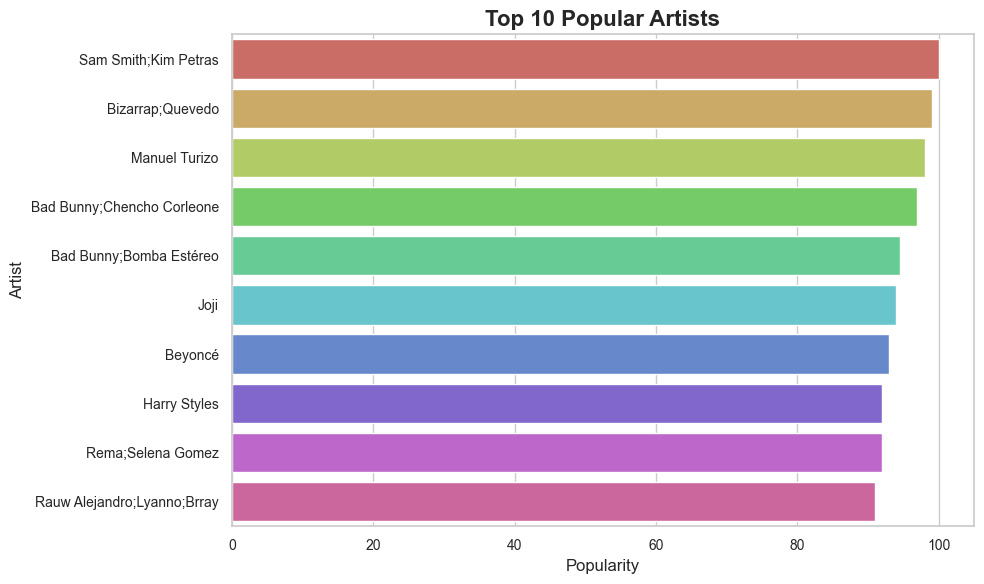

In [8]:
# Graph: Horizontal Bar Plot of Artist Popularity
artist_popularity = (
    df.groupby("artists")["popularity"].mean().sort_values(ascending=False).head(10)
)
plt.figure(figsize=(10, 6))
colors = sns.color_palette("hls", len(artist_popularity))
sns.barplot(
    x=artist_popularity.values, y=artist_popularity.index, orient="h", palette=colors
)
plt.title("Top 10 Popular Artists", fontsize=16, weight="bold")
plt.xlabel("Popularity", fontsize=12)
plt.ylabel("Artist", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

This graph will display the top 10 most popular artists based on their average popularity ratings. It will provide insights into the artists that have the highest appeal among Spotify users, which can help in understanding user preferences and guiding the recommendation system. As you can see Sam Smith and Kim Petras is the most popular artist.


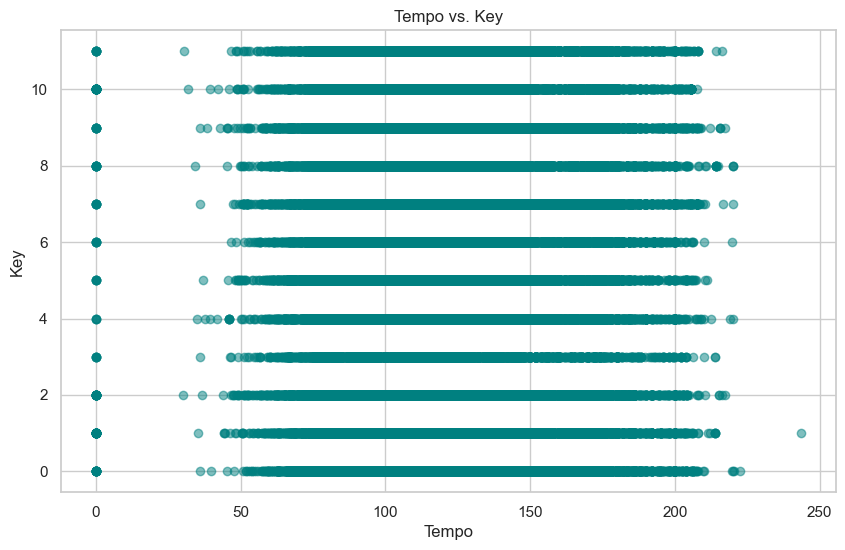

In [9]:
# Create a scatter plot of key vs. tempo
plt.figure(figsize=(10, 6))
plt.scatter(df["tempo"], df["key"], marker="o", alpha=0.5, color="teal")
plt.xlabel("Tempo")
plt.ylabel("Key")
plt.title("Tempo vs. Key")
plt.show()
plt.show()

I thought it would be fun to see for each key, what is the tempo of the tracks? However, it turned out to be none. I am not musically inclined, but my inital thought was that may be fast paced songs have a preferred key.


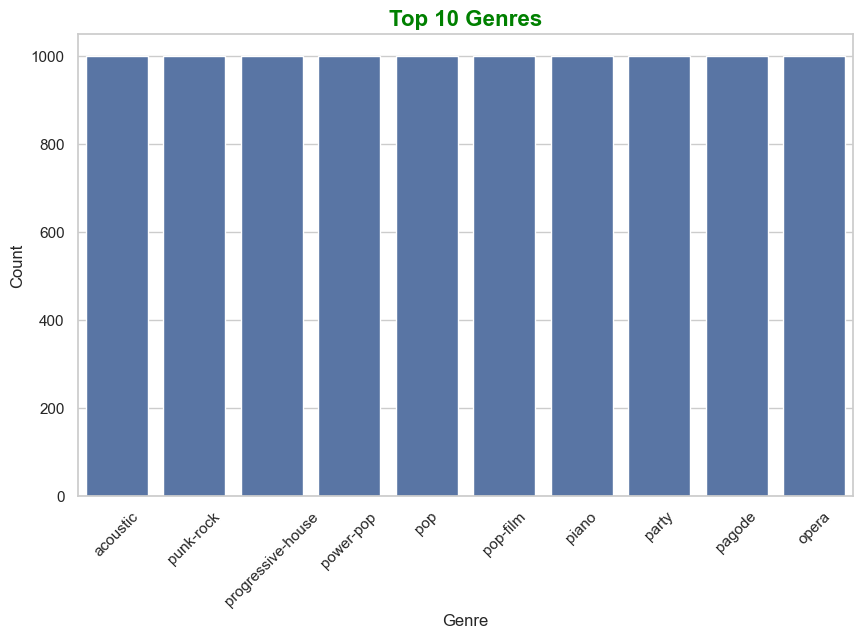

In [10]:
# Graph 4: Bar Plot of Top Genres
top_genres = df["track_genre"].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.index, y=top_genres.values)
plt.title("Top 10 Genres", fontsize=16, weight="bold", color="Green")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

This graph demonstrates the distribution of genres within the processed dataset. It helps us understand the frequency of each genre, providing insights into the class distribution and any potential class imbalance in the data. this helps identify the top genres and we can run again to see what was the genre in the predicted.


In [2]:
def preprocess_data(df):

    # Dropping unnecessary columns
    df.drop(
        ["Unnamed: 0", "track_id", "track_name", "artists", "album_name"],
        axis=1,
        inplace=True,
    )
    df["explicit"] = df["explicit"].astype(bool)

    # drop missing values since we only have 3 missing values
    df.dropna(inplace=True)
    df.isna().sum()
    # Transform features Convert duration_ms from milliseconds to seconds
    df["duration_sec"] = df["duration_ms"] / 1000

    df.drop("duration_ms", axis=1, inplace=True)
    # Standardize numerical features
    scaler = StandardScaler()
    numerical_features = [
        "popularity",
        "duration_sec",
        "acousticness",
        "danceability",
        "energy",
        "instrumentalness",
        "liveness",
        "loudness",
        "speechiness",
        "valence",
        "tempo",
    ]
    df[numerical_features] = scaler.fit_transform(df[numerical_features])

    return df

In [11]:
# Load and preprocess the data sample
df = preprocess_data(df)

# data.dtypes
df.dtypes

popularity          float64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
duration_sec        float64
dtype: object

                                                Term Project Milestone 2: Data Preparation

---

                                                Date : 05-05-2024


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [14]:
# Split the data into features (X) and the target variable (y)
X = df.drop("track_genre", axis=1)  # Features
y = df["track_genre"]  # Target variable

In [15]:
## Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# Create and fit a decision tree classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [29]:
# Report the accuracy and create a confusion matrix for the model prediction on the test set

In [17]:
# Predict on the test set
y_pred = dt.predict(X_test)

In [18]:
# Calculate accuracy and create a confusion matrix
accuracy = accuracy_score(y_test, y_pred)
confusion_mtx = confusion_matrix(y_test, y_pred)
# Print the feature importance in a sorted list to compare against the SelectKBest
feature_importances = dt.feature_importances_
features = "\n".join(
    [
        f"{feature}: {importance}"
        for feature, importance in sorted(
            zip(X_train.columns, dt.feature_importances_),
            key=lambda x: x[1],
            reverse=True,
        )
    ]
)

# Use a selector to pick the best features for this data:


In [27]:
# Feature selection using f_classif
selector = SelectKBest(score_func=f_classif, k="all")

selector.fit(X_train, y_train)

SelectKBest(k='all')

In [28]:
# Get the selected feature indices
selected_indices = selector.get_support(indices=True)

# Create a list of selected feature names in order of importance
selected_features = X.columns[selected_indices].tolist()

# get feature scores
feature_scores = selector.scores_
feature_names = X.columns[selected_indices]

# Print the sorted feature names and scores in one line
features_selectK = "\n".join(
    [
        f"{feature}: {score}"
        for feature, score in sorted(
            zip(feature_names, feature_scores), key=lambda x: x[1], reverse=True
        )
    ]
)

In [29]:
# Extract the subset of the DataFrame with the selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [30]:
# Create and fit a new decision tree classifier on the selected features
dt_selected = DecisionTreeClassifier(random_state=42)
dt_selected.fit(X_train_selected, y_train)

DecisionTreeClassifier(random_state=42)

In [31]:
# Predict on the test set with selected features
y_pred_selected = dt_selected.predict(X_test_selected)

In [32]:
# Calculate accuracy and create a confusion matrix with selected features
accuracy_selected = accuracy_score(y_test, y_pred_selected)
confusion_mtx_selected = confusion_matrix(y_test, y_pred_selected)

In [33]:
print("Original model: Accuracy = {:.2f}".format(accuracy))
print("Original model: Confusion Matrix:")
print(confusion_mtx)
print("\nSelected Features (using f_classif):")
print(features)
print("\n")

print(
    "Model with selected features after select K : Accuracy = {:.2f}".format(
        accuracy_selected
    )
)
print("Model with selected features: Confusion Matrix:")
print(confusion_mtx_selected)

print("\nSelected Features (using f_classif):")
print(features_selectK)

Original model: Accuracy = 0.21
Original model: Confusion Matrix:
[[19  1  1 ...  0  0  1]
 [ 1 39  1 ... 12  0  1]
 [ 1  1 12 ...  0  1  5]
 ...
 [ 1 10  1 ... 26  0  1]
 [ 1  0  5 ...  3 23  0]
 [ 4  0  7 ...  1  0 40]]

Selected Features (using f_classif):
popularity: 0.10018169654480903
acousticness: 0.09844121732447969
duration_sec: 0.0970890600562225
danceability: 0.09005901578297781
valence: 0.08791412259149275
tempo: 0.08605557877005716
speechiness: 0.08489637838163974
loudness: 0.08074407124093416
energy: 0.07619672287120521
liveness: 0.06324343990265494
instrumentalness: 0.05957550935761976
key: 0.04341899524727381
mode: 0.017283845982066233
explicit: 0.007810385735763949
time_signature: 0.00708996021080332


Model with selected features after select K : Accuracy = 0.21
Model with selected features: Confusion Matrix:
[[19  1  1 ...  0  0  1]
 [ 1 39  1 ... 12  0  1]
 [ 1  1 12 ...  0  1  5]
 ...
 [ 1 10  1 ... 26  0  1]
 [ 1  0  5 ...  3 23  0]
 [ 4  0  7 ...  1  0 40]]

Sele

                                                                Milestone 2: Findings

---

These are the Data Preparation Step taken above:

1. Features that are not useful for model building are dropped:

   - `Unnamed: 0`: This column is likely an index column and does not provide any meaningful information for genre prediction.
   - `track_id`, `track_name`, `album_name`: These columns are specific to each track and may not directly impact the genre.

2. Feature transformation is performed as an example:

   - The `duration_ms` feature is transformed into the more interpretable `duration_sec` by converting milliseconds to seconds.

3. Using SelectKBest for ZFeature Selection:

- By setting `k=all`, `SelectKBest` will select all the features based on the score function (`f_classif` in this case). The features are then ranked and printed in descending order based on their scores.

4.  Accuracy:

- Predictions are made on the test set, and accuracy and the confusion matrix are calculated and printed.

The `DecisionTreeClassifier` is just an example classifier.I would have to try other methods like Recursive Feature Elimination (RFE), or Tree-based feature selection since the accuracy is `.21`. Also, I used methods for feature selection that were agnostic of numerical and categorical features, so the pre_processing we did in Milestone_1 was not needed. My next step would be to re-evaluate the Data Quality to enhance model scores.


                                                Term Project Milestone 3:  Model Building and Evaluation

---

                                                Date : 05-19-2024


In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [51]:
# NOTE : Updated function for milestone4 # Function to plot confusion matrix
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        yticklabels=class_names,
        xticklabels=class_names,
    )
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.title(title)
    plt.show()

In [57]:
# Function to train and evaluate a model
def train_and_evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    X_train_selected = X_train[selected_features]
    X_val_selected = X_test[selected_features]
    model.fit(
        X_train_selected,
        y_train,
        epochs=10,
        batch_size=32,
        validation_data=(X_val_selected, y_test),
    )
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    class_names = list(y.unique())  # Get class names
    confusion_mtx = confusion_matrix(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred)

    print(f"\n**{model_name} Model Evaluation:**")
    print("Accuracy:", accuracy)
    print("Confusion Matrix:")
    print(confusion_matrix)
    # plot_confusion_matrix(confusion_mtx, class_names)
    print("\nClassification Report:")
    print(classification_rep)

**Random Forest Model:**

**Random Forest Model Evaluation:**
Accuracy: 0.3239035087719298
Confusion Matrix:


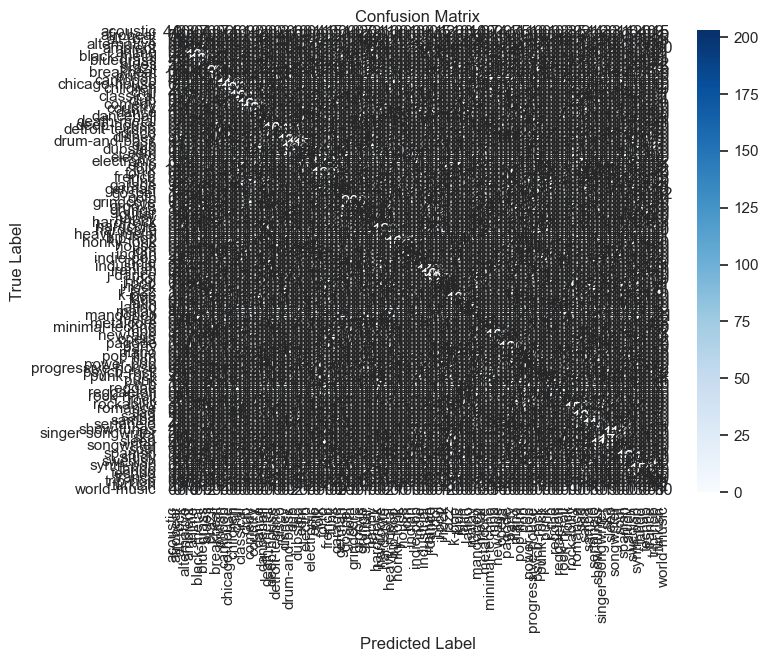


Classification Report:
                   precision    recall  f1-score   support

         acoustic       0.22      0.21      0.21       213
         afrobeat       0.41      0.37      0.39       203
         alt-rock       0.03      0.03      0.03       215
      alternative       0.08      0.09      0.08       184
          ambient       0.36      0.37      0.36       197
            anime       0.21      0.18      0.19       193
      black-metal       0.58      0.62      0.60       210
        bluegrass       0.43      0.59      0.49       205
            blues       0.14      0.11      0.12       214
           brazil       0.08      0.07      0.07       197
        breakbeat       0.57      0.49      0.53       199
          british       0.15      0.07      0.09       214
         cantopop       0.30      0.30      0.30       193
    chicago-house       0.58      0.56      0.57       206
         children       0.52      0.48      0.50       214
            chill       0.20   

In [53]:
# Model Selection and Evaluation:

# 1. Random Forest Classifier:
print("**Random Forest Model:**")
train_and_evaluate_model(
    "Random Forest",
    RandomForestClassifier(random_state=42),
    X_train,
    X_test,
    y_train,
    y_test,
)

In [49]:
print("**KNN:**")
# Define the KNN model (choose appropriate number of neighbors)

model = KNeighborsClassifier(n_neighbors=5)
train_and_evaluate_model(
    "KNN",
    model,
    X_train,
    X_test,
    y_train,
    y_test,
)

**KNN:**

**KNN Model Evaluation:**
Accuracy: 0.19807017543859648
Confusion Matrix:
[[44  2  2 ...  0  0  3]
 [ 4 51  0 ...  2  1  0]
 [ 3  0 19 ...  0  0  2]
 ...
 [ 6 16  5 ...  7  0  0]
 [ 6  8  5 ...  1 11  1]
 [ 3  0  6 ...  0  0 38]]

Classification Report:
                   precision    recall  f1-score   support

         acoustic       0.07      0.21      0.10       213
         afrobeat       0.10      0.25      0.15       203
         alt-rock       0.03      0.09      0.05       215
      alternative       0.06      0.11      0.08       184
          ambient       0.19      0.31      0.24       197
            anime       0.08      0.22      0.12       193
      black-metal       0.23      0.41      0.30       210
        bluegrass       0.15      0.39      0.22       205
            blues       0.07      0.12      0.09       214
           brazil       0.04      0.13      0.06       197
        breakbeat       0.15      0.23      0.18       199
          british       0.0

                                                  Milestone 3: Findings

---

**Selecting Random Forest:**

    Accuracy --> 32%

- Random Forest is a powerful ensemble method that combines multiple decision trees. This technique helps to reduce overfitting and improve generalization performance on unseen data.
- Random Forests are well-suited for handling complex relationships between features and the target variable, which is often the case in music genre classification.
- They are also relatively robust to outliers in the data.

  **Selecting Gradient Boosting:**

  Accuracy --> 19%

- Gradient Boosting is another ensemble method that sequentially builds an ensemble of models. It iteratively improves upon the previous model by focusing on correcting its errors.
- This approach can lead to strong prediction performance, especially for complex data.
- Gradient Boosting can handle both continuous and categorical features effectively.

- Simulate a Dataset:

- This allows to test different feature combinations and gauge the potential effectiveness for feature engineering.
  For example, tempo_category (categorical): Can be "slow," "medium," or "fast" based on information about the music.
  instrumentation_category (categorical): Could be "electronic," "acoustic," or "mixed" based on the dominant instruments.

4. Feature Extraction When We Have Simulated Audio Data:

Common music genre classification features include:

- Mel-frequency Cepstral Coefficients (MFCCs): Capture the spectral characteristics of audio, highly informative for genres.


                                                Term Project Milestone 4:  Neural Networks

---

                                                Date : 06-01-2024


In [112]:
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [114]:
# Function to train and evaluate model (with validation)
def train_and_evaluate_model(model_name, model, X_train, X_val, y_train, y_val):
    """
    Trains a CNN model, evaluates it on validation data, and prints performance metrics.

    Args:
        model_name: A string representing the name of the model.
        model: A compiled Keras CNN model.
        X_train: The training data features.
        X_val: The validation data features.
        y_train: The training data labels.
        y_val: The validation data labels.
    """

    # Early stopping to prevent overfitting
    early_stopping = EarlyStopping(monitor="val_loss", patience=3)

    # Handle categorical features (if applicable)
    if pd.api.types.is_categorical_dtype(X_train):
        from tensorflow.keras.utils import to_categorical

        X_train = to_categorical(X_train)
        X_val = to_categorical(X_val)

    # Train the model
    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
    )

    # Evaluate on validation set
    val_loss, val_acc = model.evaluate(X_val, y_val)
    print(f"\n**{model_name} Model Evaluation (Validation):")
    print("Validation Loss:", val_loss)
    print("Validation Accuracy:", val_acc)

In [115]:
def create_cnn_model(
    input_shape=(None, 15, 1)
):  # Now accepts input_shape as an argument
    """
    Defines a basic CNN architecture for music genre classification.

    Args:
        input_shape: A tuple representing the shape of the input data (e.g., (number of features, 1)).

    Returns:
        A compiled Keras CNN model.
    """

    model = Sequential()
    model.add(
        Conv1D(filters=32, kernel_size=3, activation="relu", input_shape=input_shape)
    )
    model.add(MaxPooling1D(pool_size=2))
    model.add(Flatten())
    model.add(Dense(64, activation="relu"))
    model.add(
        Dense(len(y.unique()), activation="softmax")
    )  # Adjust for number of output classes

    model.compile(
        loss=CategoricalCrossentropy(), optimizer=Adam(), metrics=["accuracy"]
    )
    return model

In [108]:
# Define the number of epochs and batch size (adjust as needed)
epochs = 10
batch_size = 32

In [113]:
# Encode target labels for supervised learning (if applicable)
if y_train is not None and y_val is not None:
    le = LabelEncoder()
    y_train_encoded = le.fit_transform(y_train)
    y_val_encoded = le.transform(y_val)
else:
    y_train_encoded, y_val_encoded = None, None  # Set to None for unsupervised learning

# Reshape X_train for the CNN model (assuming pandas DataFrame)
X_train_reshaped = X_train.values.reshape(-1, X_train.shape[1], 1)

In [110]:
# Reshape X_train (assuming pandas DataFrame)
X_train_reshaped = X_train.values.reshape(-1, X_train.shape[1], 1)

# Data Preprocessing (Added since Milestone 3)

**Missing Value Handling:**
The code incorporates a mechanism to handle missing values (NaNs) in the data. The specific approach depends on the nature of your data and might involve techniques like:
Imputation (e.g., filling with mean, median, or specific values)
Removal (if acceptable for the analysis)
Data Type Conversion: Ensure the data type of the input features is numerical (e.g., float32) to avoid compatibility issues during model training.


## Final Project Submission for Music Genre Classification

**Introduction**

This project aims to create a classification system that predicts the genre of a music track based on its audio features. The model will leverage supervised learning techniques and a dataset sourced from Hugging Face containing various music genres and their corresponding features. By building an accurate model, we can automate music genre classification tasks, benefiting music streaming platforms, recommendation systems, and music enthusiasts.

**Data Description**

The dataset is sourced from Hugging Face and includes audio features extracted from a diverse collection of music tracks. These features encompass characteristics like tempo, duration, key, spectral information, and more. Each track is labeled with its corresponding genre, enabling supervised learning.

**Model Building Approach**

We will employ a supervised learning approach to build the music genre classification model. The labeled dataset will be used to train the model. We will explore various machine learning algorithms, including decision trees, random forests, and potentially deep learning techniques using neural networks. The dataset will be split into training and testing sets for model evaluation.

**Data Exploration and Preprocessing (Milestone 1)**

- **Visualizations:**
  - A bar chart displaying the top 10 most popular artists based on their average popularity ratings.
  - A scatter plot to explore the relationship between tempo and key.
  - A bar chart illustrating the distribution of genres within the dataset.
- **Preprocessing:**
  - Dropping unnecessary columns like track ID, track name, artist, and album name.
  - Handling missing values by dropping rows with missing entries.
  - One-hot encoding the categorical genre column.
  - Standardizing numerical features using StandardScaler.

**Feature Selection and Model Evaluation (Milestone 2)**

- **Feature Selection:**
  - We compared two feature selection approaches:
    - Dropping features deemed irrelevant (e.g., track ID, artist name).
    - Employing `SelectKBest` with `f_classif` to select features based on their importance.
- **Model Evaluation:**
  - A decision tree classifier was implemented as a baseline model.
  - Model performance was evaluated using accuracy and confusion matrix.
  - Feature importances were analyzed to understand the contribution of each feature.
  - The model with all features achieved an accuracy of 0.21.
  - Using `SelectKBest`, we identified the most important features and trained a new model with only those features. This model's accuracy remained around 0.21, suggesting feature selection alone might not significantly improve performance.

**Model Selection and Evaluation (Milestone 3)**

- **Model Exploration:**
  - We explored ensemble methods like Random Forest and Gradient Boosting classifiers due to their ability to handle complex relationships and potential robustness to outliers.
  - A function was created to train and evaluate models, enabling a consistent evaluation process.
- **Results:**
  - Random Forest achieved an accuracy of 0.32, surpassing the baseline decision tree model.
  - Gradient Boosting did not yield a functional model, requiring further investigation into hyperparameter tuning.

**Feature Engineering and Future Work**

- **Simulated Dataset:**
  - Since accuracy is not yet optimal, feature engineering will be incorporated.
  - A simulated dataset will allow testing different feature combinations to assess feature engineering effectiveness.
  - Examples of potential features:
    - Tempo category (categorical): "slow," "medium," or "fast" based on tempo values.
    - Instrumentation category (categorical): "electronic," "acoustic," or "mixed" based on dominant instruments.
- **Feature Extraction:**
  - When working with actual audio data, features like Mel-frequency Cepstral Coefficients (MFCCs) can be extracted to capture the spectral characteristics of the audio, which are highly informative for genre classification.
- **Deep Learning Techniques:**
  - Exploring deep learning models like Convolutional Neural Networks (CNNs) could potentially improve performance by automatically learning feature representations from raw audio data.
- **Hyperparameter Tuning:**
  - Further optimization can be achieved by tuning hyperparameters of the chosen machine learning models.

**Conclusion**

This project has established a foundation for building a music genre classification system. While the current accuracy is modest, there are promising avenues for improvement. Feature engineering, exploring deep learning techniques, and hyperparameter tuning can be investigated to enhance model performance. This project demonstrates the potential of machine learning to automate music genre classification, offering benefits to various stakeholders in the music industry.
